Conectado. Aguardando dados do degrau...
t_ms,velocidade_rad_s
19,-1.017905
40,-2.981604
59,-4.508768
80,-5.745043
100,-6.689091
120,-7.417650
140,-7.999426
160,-8.581203
180,-8.943025
200,-9.306562
220,-9.599312
239,-9.888222
260,-10.035644
279,-10.253810
300,-10.326532
319,-10.471977
340,-10.542590
359,-10.688005
380,-10.688005
400,-10.762866
420,-10.833420
440,-10.831254
460,-10.833420
480,-10.906127
500,-10.906127
520,-10.906127
539,-10.981031
560,-10.908309
579,-10.981031
600,-10.978835
619,-10.978835
640,-10.978835
659,-10.978835
680,-10.978835
700,-11.053752
720,-10.981031
740,-10.974446
760,-10.981031
780,-10.981031
800,-10.981031
820,-11.051542
840,-10.981031
860,-11.051542
879,-10.981031
900,-11.053752
919,-10.981031
940,-11.051542
959,-11.051542
980,-10.981031
1000,-11.053752
1020,-11.051542
1040,-10.972253
1060,-10.978835
1080,-11.051542
1100,-11.053752
1120,-11.047124
1140,-10.978835
1160,-11.053752
1179,-10.978835
1200,-11.051542
1219,-10.976640
1240,-10.981031
1259,-11.0

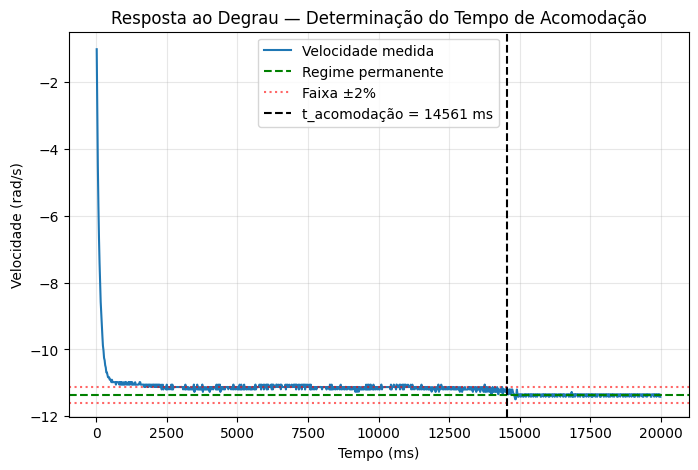


Sugestão de T_ACOMODACAO para o ensaio completo: 21842 ms (~21.84 s)


In [10]:
import serial
import csv
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PORTA = "COM6"
BAUDRATE = 9600
ARQUIVO_SAIDA = "resposta_degrau200_e.csv"


def capturar_degrau(porta, baudrate, arquivo_saida):
    with serial.Serial(porta, baudrate, timeout=2) as ser, \
         open(arquivo_saida, "w", newline="") as f:

        writer = csv.writer(f)
        print("Conectado. Aguardando dados do degrau...")
        time.sleep(2)

        while True:
            linha = ser.readline().decode("utf-8", errors="ignore").strip()
            if not linha:
                continue
            print(linha)

            if linha == "FIM_DEGRAU":
                print("Captura concluída.")
                break

            writer.writerow(linha.split(","))
            f.flush()


def calcular_tempo_acomodacao(arquivo_csv, tolerancia=0.02, janela_estavel_ms=300):
    """
    Calcula o tempo de acomodação (settling time) a partir da resposta ao degrau.

    tolerancia: faixa em torno do valor final (ex: 0.02 = ±2%)
    janela_estavel_ms: tempo mínimo que a resposta deve permanecer dentro
                        da faixa para ser considerada "acomodada"
    """
    df = pd.read_csv(arquivo_csv, header=0, names=["t_ms", "vel"])
    df = df.dropna()
    df["t_ms"] = pd.to_numeric(df["t_ms"], errors="coerce")
    df["vel"] = pd.to_numeric(df["vel"], errors="coerce")
    df = df.dropna().reset_index(drop=True)

    # valor de regime permanente: média dos últimos 20% dos dados
    n_final = max(5, int(len(df) * 0.2))
    vel_regime = df["vel"].iloc[-n_final:].mean()

    faixa_sup = vel_regime * (1 + tolerancia)
    faixa_inf = vel_regime * (1 - tolerancia)

    dentro_faixa = df["vel"].between(min(faixa_inf, faixa_sup),
                                      max(faixa_inf, faixa_sup))

    # procura o primeiro instante a partir do qual a resposta
    # permanece dentro da faixa por pelo menos "janela_estavel_ms"
    t_acomodacao = None
    for i in range(len(df)):
        if dentro_faixa.iloc[i:].all():  # permanece estável até o fim
            t_acomodacao = df["t_ms"].iloc[i]
            break

    print(f"Velocidade em regime permanente: {vel_regime:.4f} rad/s")
    print(f"Tempo de acomodação (±{tolerancia*100:.0f}%): {t_acomodacao:.0f} ms")

    # -------- Plot --------
    plt.figure(figsize=(8, 5))
    plt.plot(df["t_ms"], df["vel"], label="Velocidade medida")
    plt.axhline(vel_regime, color="green", linestyle="--", label="Regime permanente")
    plt.axhline(faixa_sup, color="red", linestyle=":", alpha=0.6)
    plt.axhline(faixa_inf, color="red", linestyle=":", alpha=0.6, label=f"Faixa ±{tolerancia*100:.0f}%")
    if t_acomodacao is not None:
        plt.axvline(t_acomodacao, color="black", linestyle="--",
                    label=f"t_acomodação = {t_acomodacao:.0f} ms")
    plt.xlabel("Tempo (ms)")
    plt.ylabel("Velocidade (rad/s)")
    plt.title("Resposta ao Degrau — Determinação do Tempo de Acomodação")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return t_acomodacao, vel_regime


if __name__ == "__main__":
    capturar_degrau(PORTA, BAUDRATE, ARQUIVO_SAIDA)
    t_acom, v_reg = calcular_tempo_acomodacao(ARQUIVO_SAIDA, tolerancia=0.02)

    # Sugestão de T_ACOMODACAO com margem de segurança
    margem = 1.5  # 50% de folga
    print(f"\nSugestão de T_ACOMODACAO para o ensaio completo: "
          f"{t_acom * margem:.0f} ms (~{t_acom * margem / 1000:.2f} s)")

Sugestão de T_ACOMODACAO para o ensaio completo: 29703 ms (~29.70 s)